In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt

print("MNE version:", mne.__version__)

MNE version: 1.12.1


In [5]:
import os

print("Current directory:")
print(os.getcwd())

Current directory:
C:\Users\DELL\Desktop\eeg-cognitive-control-erp-analysis\notebooks


In [7]:
from mne.datasets import sample

data_path = sample.data_path()

raw_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"

raw = mne.io.read_raw_fif(raw_file, preload=True)

Using default location ~/mne_data for sample...
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of 'C:\Users\DELL\mne_data\MNE-sample-data-processed.tar.gz' to 'C:\Users\DELL\mne_data'


Attempting to create new mne-python configuration file:
C:\Users\DELL\.mne\mne-python.json
Could not read the C:\Users\DELL\.mne\mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 02h27m07s (1576.2 MB)
Opening raw data file C:\Users\DELL\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [8]:
print(raw)

<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>


In [9]:
print (raw.info)

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>


In [10]:
print(raw.info["bads"])
#It means EEG electrode/channel 53 is considered bad/unreliable.

['MEG 2443', 'EEG 053']


In [ ]:
## Event Detection

EEG is recorded continuously. To perform ERP analysis, we need to identify
the time points at which experimental events occurred.

In this dataset, event information is encoded in a stimulus channel.

In [12]:
events = mne.find_events(raw)
print(events)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[ 27977      0      2]
 [ 28345      0      3]
 [ 28771      0      1]
 [ 29219      0      4]
 [ 29652      0      2]
 [ 30025      0      3]
 [ 30450      0      1]
 [ 30839      0      4]
 [ 31240      0      2]
 [ 31665      0      3]
 [ 32101      0      1]
 [ 32519      0      4]
 [ 32935      0      2]
 [ 33325      0      3]
 [ 33712      0      1]
 [ 34089      0      5]
 [ 34532      0      2]
 [ 34649      0     32]
 [ 34956      0      3]
 [ 35428      0      1]
 [ 35850      0      4]
 [ 36211      0      2]
 [ 36576      0      3]
 [ 37007      0      1]
 [ 37460      0      4]
 [ 37910      0      2]
 [ 38326      0      3]
 [ 38711      0      1]
 [ 39130      0      4]
 [ 39563      0      2]
 [ 39926      0      3]
 [ 40405      0      1]
 [ 40880      0      4]
 [ 41260      0      2]
 [ 41646      0      3]
 [ 42126      0      1]
 [ 42598      0      5]
 [ 42938     

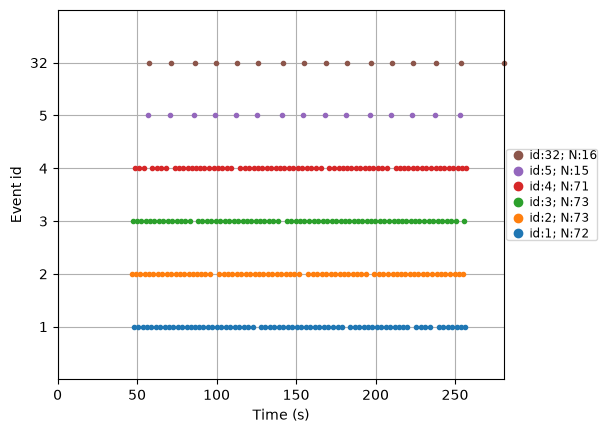

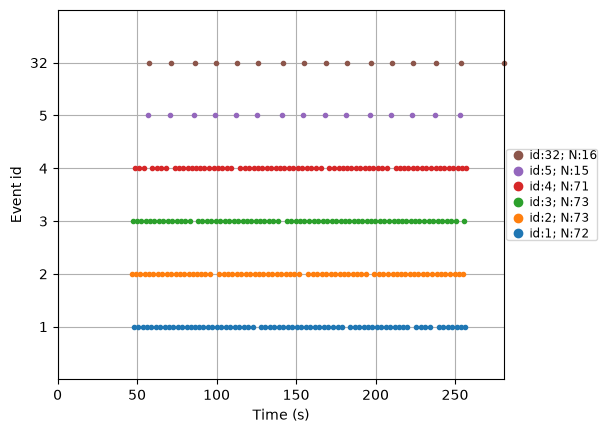

In [15]:
mne.viz.plot_events(
    events,
    sfreq=raw.info["sfreq"]
)

In [16]:
import numpy as np

event_ids, counts = np.unique(events[:, 2], return_counts=True)

for event_id, count in zip(event_ids, counts):
    print(f"Event {event_id}: {count} occurrences")

Event 1: 72 occurrences
Event 2: 73 occurrences
Event 3: 73 occurrences
Event 4: 71 occurrences
Event 5: 15 occurrences
Event 32: 16 occurrences
